In [17]:
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei']
mpl.rcParams['axes.unicode_minus'] = False

In [18]:
print("="*50)
print("2.1 理论计算题")
print("="*50)

print("1. 线性激活的MLP等价于单层神经网络：")
print("   隐藏层：h = W1 x + b1")
print("   输出层：o = W2 h + b2 = W2 (W1 x + b1) + b2 = (W2 W1) x + (W2 b1 + b2)")
print("   因此等价权重 W' = W2 W1，偏置 b' = W2 b1 + b2")
print()
print("2. 激活函数性质：")
print("   Sigmoid(x) = 1/(1+exp(-x))")
print("   Sigmoid'(x) = Sigmoid(x) * (1 - Sigmoid(x))")
print("   tanh(x) = (exp(x)-exp(-x))/(exp(x)+exp(-x))")
print("   tanh'(x) = 1 - tanh(x)^2")

2.1 理论计算题
1. 线性激活的MLP等价于单层神经网络：
   隐藏层：h = W1 x + b1
   输出层：o = W2 h + b2 = W2 (W1 x + b1) + b2 = (W2 W1) x + (W2 b1 + b2)
   因此等价权重 W' = W2 W1，偏置 b' = W2 b1 + b2

2. 激活函数性质：
   Sigmoid(x) = 1/(1+exp(-x))
   Sigmoid'(x) = Sigmoid(x) * (1 - Sigmoid(x))
   tanh(x) = (exp(x)-exp(-x))/(exp(x)+exp(-x))
   tanh'(x) = 1 - tanh(x)^2



2.2 编程题：从零实现MLP多分类 (Fashion-MNIST)
Epoch  5/20, Loss: 0.3527
Epoch 10/20, Loss: 0.2904
Epoch 15/20, Loss: 0.2560
Epoch 20/20, Loss: 0.2311

测试集准确率: 87.63%


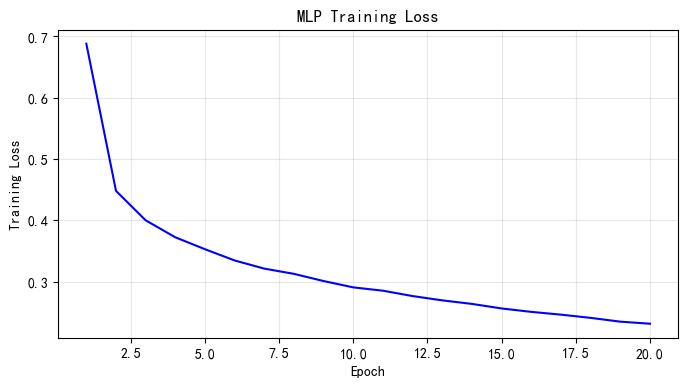

In [19]:
print("\n" + "="*50)
print("2.2 编程题：从零实现MLP多分类 (Fashion-MNIST)")
print("="*50)

# 加载Fashion-MNIST数据集
import torch
from torchvision import datasets, transforms
import numpy as np
from sklearn.metrics import accuracy_score

transform = transforms.Compose([transforms.ToTensor(), transforms.Lambda(lambda x: x.view(-1))])
train_dataset = datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

X_train = train_dataset.data.numpy().reshape(-1, 784) / 255.0
y_train = train_dataset.targets.numpy()
X_test = test_dataset.data.numpy().reshape(-1, 784) / 255.0
y_test = test_dataset.targets.numpy()

# 超参数
input_size = 784
hidden_size = 256
num_classes = 10
batch_size = 64
lr = 0.1
epochs = 20

# 参数初始化（正态分布）
W1 = np.random.randn(input_size, hidden_size) * 0.01
b1 = np.zeros((1, hidden_size))
W2 = np.random.randn(hidden_size, num_classes) * 0.01
b2 = np.zeros((1, num_classes))

def relu(x):
    return np.maximum(0, x)

def softmax(logits):
    exp_logits = np.exp(logits - np.max(logits, axis=1, keepdims=True))
    return exp_logits / np.sum(exp_logits, axis=1, keepdims=True)

def cross_entropy_loss(probs, y):
    n = probs.shape[0]
    log_probs = -np.log(probs[np.arange(n), y] + 1e-8)
    return np.mean(log_probs)

num_samples = X_train.shape[0]
loss_history = []

for epoch in range(epochs):
    indices = np.random.permutation(num_samples)
    X_shuffled = X_train[indices]
    y_shuffled = y_train[indices]
    
    epoch_loss = 0
    num_batches = 0
    for i in range(0, num_samples, batch_size):
        X_batch = X_shuffled[i:i+batch_size]
        y_batch = y_shuffled[i:i+batch_size]
        
        # 前向传播
        h = relu(np.dot(X_batch, W1) + b1)
        logits = np.dot(h, W2) + b2
        probs = softmax(logits)
        loss = cross_entropy_loss(probs, y_batch)
        epoch_loss += loss
        num_batches += 1
        
        # 反向传播
        dlogits = probs
        dlogits[np.arange(len(y_batch)), y_batch] -= 1
        dlogits /= batch_size
        
        dW2 = np.dot(h.T, dlogits)
        db2 = np.sum(dlogits, axis=0, keepdims=True)
        
        dh = np.dot(dlogits, W2.T)
        dh[h <= 0] = 0
        
        dW1 = np.dot(X_batch.T, dh)
        db1 = np.sum(dh, axis=0, keepdims=True)
        
        W2 -= lr * dW2
        b2 -= lr * db2
        W1 -= lr * dW1
        b1 -= lr * db1
    
    avg_loss = epoch_loss / num_batches
    loss_history.append(avg_loss)
    if (epoch+1) % 5 == 0:
        print(f"Epoch {epoch+1:2d}/{epochs}, Loss: {avg_loss:.4f}")

h_test = relu(np.dot(X_test, W1) + b1)
logits_test = np.dot(h_test, W2) + b2
y_pred = np.argmax(logits_test, axis=1)
accuracy = accuracy_score(y_test, y_pred)
print(f"\n测试集准确率: {accuracy*100:.2f}%")

import matplotlib.pyplot as plt
plt.figure(figsize=(8,4))
plt.plot(range(1, epochs+1), loss_history, 'b-')
plt.xlabel('Epoch')
plt.ylabel('Training Loss')
plt.title('MLP Training Loss')
plt.grid(alpha=0.3)
plt.show()

In [20]:
print("\n" + "="*50)
print("3.1 理论计算题")
print("="*50)
print("1. 训练误差是模型在训练集上的误差，泛化误差是模型在未见过的测试集上的误差。")
print("   当训练误差极低但泛化误差很高时，模型处于过拟合状态。")
print("   缓解过拟合的方法：降低模型复杂度（减少层数、神经元数）、正则化（L2, Dropout）、早停、数据增强等。")
print()
print("2. K折交叉验证步骤：")
print("   (1) 将数据集随机划分为K个大小相等的子集。")
print("   (2) 对于每个子集 i=1..K：将该子集作为验证集，其余K-1个子集合并作为训练集。")
print("   (3) 在训练集上训练模型，在验证集上评估性能，记录性能指标。")
print("   (4) 重复K次后，计算K次性能指标的平均值作为最终评估结果。")


3.1 理论计算题
1. 训练误差是模型在训练集上的误差，泛化误差是模型在未见过的测试集上的误差。
   当训练误差极低但泛化误差很高时，模型处于过拟合状态。
   缓解过拟合的方法：降低模型复杂度（减少层数、神经元数）、正则化（L2, Dropout）、早停、数据增强等。

2. K折交叉验证步骤：
   (1) 将数据集随机划分为K个大小相等的子集。
   (2) 对于每个子集 i=1..K：将该子集作为验证集，其余K-1个子集合并作为训练集。
   (3) 在训练集上训练模型，在验证集上评估性能，记录性能指标。
   (4) 重复K次后，计算K次性能指标的平均值作为最终评估结果。



3.2 编程题：L2正则化与Dropout对比实验
无正则化: 测试MSE = 0.0577
权重衰减 (L2=0.1): 测试MSE = 0.0889
Dropout (p=0.5): 测试MSE = 0.1076


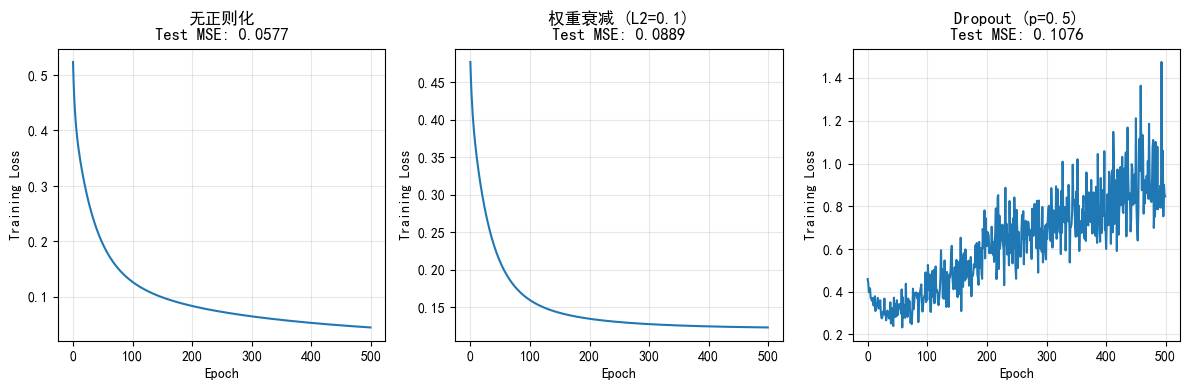

In [21]:
print("\n" + "="*50)
print("3.2 编程题：L2正则化与Dropout对比实验")
print("="*50)

np.random.seed(42)
n_train = 50
n_test = 200
deg = 20

x_train = np.random.uniform(-3, 3, n_train)
x_test = np.random.uniform(-3, 3, n_test)
y_train = np.sin(x_train) + np.random.normal(0, 0.1, n_train)
y_test = np.sin(x_test) + np.random.normal(0, 0.1, n_test)

def poly_features(x, deg):
    return np.vstack([x**i for i in range(1, deg+1)]).T

X_train_poly = poly_features(x_train, deg)
X_test_poly = poly_features(x_test, deg)

mean = X_train_poly.mean(axis=0)
std = X_train_poly.std(axis=0) + 1e-8
X_train_poly = (X_train_poly - mean) / std
X_test_poly = (X_test_poly - mean) / std

def mse_loss(y_pred, y_true):
    return np.mean((y_pred - y_true) ** 2)

def train_linear_regression(X, y, lr=0.01, epochs=1000, lambda_l2=0.0, dropout_prob=0.0, is_training=True):
    n, d = X.shape
    W = np.random.randn(d) * 0.01
    b = 0.0
    losses = []
    for epoch in range(epochs):
        if is_training and dropout_prob > 0:
            mask = (np.random.rand(*X.shape) > dropout_prob) / (1 - dropout_prob)
            X_drop = X * mask
            y_pred = np.dot(X_drop, W) + b
        else:
            y_pred = np.dot(X, W) + b
        loss = mse_loss(y_pred, y) + lambda_l2 * np.sum(W**2)
        losses.append(loss)
        grad_W = 2 * np.dot(X.T, (y_pred - y)) / n + 2 * lambda_l2 * W
        grad_b = 2 * np.mean(y_pred - y)
        W -= lr * grad_W
        b -= lr * grad_b
    return W, b, losses

configs = [
    ("无正则化", 0.0, 0.0),
    ("权重衰减 (L2=0.1)", 0.1, 0.0),
    ("Dropout (p=0.5)", 0.0, 0.5)
]

plt.figure(figsize=(12, 4))
for i, (name, lam, drop) in enumerate(configs):
    W, b, losses = train_linear_regression(X_train_poly, y_train, lr=0.01, epochs=500, lambda_l2=lam, dropout_prob=drop, is_training=True)
    y_pred_test = np.dot(X_test_poly, W) + b
    test_mse = mse_loss(y_pred_test, y_test)
    print(f"{name}: 测试MSE = {test_mse:.4f}")
    plt.subplot(1, 3, i+1)
    plt.plot(losses)
    plt.title(f"{name}\nTest MSE: {test_mse:.4f}")
    plt.xlabel('Epoch')
    plt.ylabel('Training Loss')
    plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [22]:
print("\n" + "="*50)
print("4.1 理论计算题")
print("="*50)
print("1. 梯度爆炸：当连乘项中矩阵的谱半径 > 1，或激活函数导数 > 1 且权重较大时，梯度指数增长。")
print("   梯度消失：当连乘项中矩阵的谱半径 < 1，或激活函数导数很小（如Sigmoid导数≤0.25）且权重较小时，梯度指数衰减。")
print("2. ReLU在正半轴导数为1，不存在饱和区，梯度可以完整传播，因此缓解了梯度消失问题。")


4.1 理论计算题
1. 梯度爆炸：当连乘项中矩阵的谱半径 > 1，或激活函数导数 > 1 且权重较大时，梯度指数增长。
   梯度消失：当连乘项中矩阵的谱半径 < 1，或激活函数导数很小（如Sigmoid导数≤0.25）且权重较小时，梯度指数衰减。
2. ReLU在正半轴导数为1，不存在饱和区，梯度可以完整传播，因此缓解了梯度消失问题。


In [23]:
print("\n" + "="*50)
print("4.2 编程题：深层网络梯度稳定性实验")
print("="*50)

import torch.nn as nn

def build_model(activation, init_method='normal', std=1.0):
    layers = []
    for _ in range(20):
        linear = nn.Linear(256, 256)
        if init_method == 'normal':
            nn.init.normal_(linear.weight, mean=0, std=std)
        elif init_method == 'xavier':
            nn.init.xavier_uniform_(linear.weight)
        layers.append(linear)
        if activation == 'sigmoid':
            layers.append(nn.Sigmoid())
        elif activation == 'relu':
            layers.append(nn.ReLU())
    return nn.Sequential(*layers)

def compute_gradient_norms(model, x):
    x.requires_grad_(True)
    out = model(x)
    loss = out.sum()
    loss.backward()
    norms = []
    for name, param in model.named_parameters():
        if param.grad is not None:
            norms.append(param.grad.norm().item())
    return norms

configs = [
    ("Sigmoid + 标准初始化 (std=1)", 'sigmoid', 'normal', 1.0),
    ("ReLU + 大初始化 (std=10)", 'relu', 'normal', 10.0),
    ("ReLU + Xavier初始化", 'relu', 'xavier', None)
]

x = torch.randn(1, 256)

for name, act, init, std in configs:
    print(f"\n{name}")
    model = build_model(act, init, std if std else 1.0)
    norms = compute_gradient_norms(model, x)
    print("前5层梯度范数:", norms[:5])
    print("后5层梯度范数:", norms[-5:])
    if any(np.isnan(n) for n in norms):
        print("出现NaN（梯度爆炸/数值溢出）")
    else:
        print("梯度范数范围: [{:.2e}, {:.2e}]".format(min(norms), max(norms)))
        if max(norms) > 1e3:
            print("警告：梯度范数过大，可能梯度爆炸")
        if min(norms) < 1e-6:
            print("警告：梯度范数过小，可能梯度消失")
    del model


4.2 编程题：深层网络梯度稳定性实验

Sigmoid + 标准初始化 (std=1)
前5层梯度范数: [676.25927734375, 42.08866500854492, 343.9153747558594, 30.219594955444336, 311.1413879394531]
后5层梯度范数: [2.110203742980957, 18.591289520263672, 1.692177414894104, 14.835047721862793, 1.3379790782928467]
梯度范数范围: [1.34e+00, 6.76e+02]

ReLU + 大初始化 (std=10)
前5层梯度范数: [inf, inf, inf, inf, inf]
后5层梯度范数: [302046.875, inf, 2628.741455078125, nan, 16.0]
出现NaN（梯度爆炸/数值溢出）

ReLU + Xavier初始化
前5层梯度范数: [0.23284079134464264, 0.014491396024823189, 0.214199498295784, 0.019788261502981186, 0.20798712968826294]
后5层梯度范数: [6.292354106903076, 4.811305999755859, 8.598376274108887, 6.335381031036377, 11.180339813232422]
梯度范数范围: [1.45e-02, 1.12e+01]


In [24]:
print("\n" + "="*50)
print("5.1 理论计算题")
print("="*50)
print("协变量偏移：特征分布改变，但条件标签分布不变。例如：医疗诊断中训练集来自年轻人，测试集来自老年人。")
print("标签偏移：标签分布改变，但特征给定标签的分布不变。例如：电商中训练集平时购买行为，测试集为促销期间（购买比例变化）。")
print("区别：协变量偏移关注输入分布变化，标签偏移关注输出分布变化。联系：均导致训练与测试分布不一致。")


5.1 理论计算题
协变量偏移：特征分布改变，但条件标签分布不变。例如：医疗诊断中训练集来自年轻人，测试集来自老年人。
标签偏移：标签分布改变，但特征给定标签的分布不变。例如：电商中训练集平时购买行为，测试集为促销期间（购买比例变化）。
区别：协变量偏移关注输入分布变化，标签偏移关注输出分布变化。联系：均导致训练与测试分布不一致。



5.2 编程题：协变量偏移校正
基线模型测试MSE: 0.0102
加权模型测试MSE: 0.0222
MSE改善: -0.0120 (-118.30%)


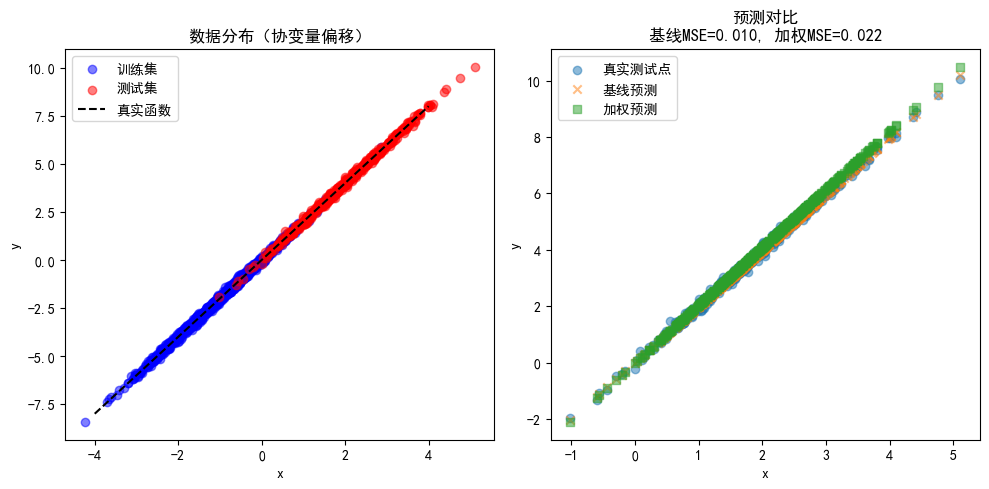

In [25]:
print("\n" + "="*50)
print("5.2 编程题：协变量偏移校正")
print("="*50)

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

np.random.seed(42)
n_train = 1000
n_test = 500

x_train = np.random.normal(-1, 1, n_train)
y_train = 2 * x_train + np.random.normal(0, 0.1, n_train)
x_test = np.random.normal(2, 1, n_test)
y_test = 2 * x_test + np.random.normal(0, 0.1, n_test)

# 基线模型
model_baseline = LinearRegression()
model_baseline.fit(x_train.reshape(-1,1), y_train)
y_pred_baseline = model_baseline.predict(x_test.reshape(-1,1))
mse_baseline = mean_squared_error(y_test, y_pred_baseline)
print(f"基线模型测试MSE: {mse_baseline:.4f}")

# 训练权重分类器 - 修复vstack错误
X_combined = np.vstack([x_train.reshape(-1,1), x_test.reshape(-1,1)])
y_combined = np.hstack([np.zeros(n_train), np.ones(n_test)])
clf = LogisticRegression()
clf.fit(X_combined, y_combined)
prob_test = clf.predict_proba(x_train.reshape(-1,1))[:, 1]
prob_train = 1 - prob_test
weights = prob_test / (prob_train + 1e-8)
weights = weights / np.sum(weights) * n_train

# 加权线性回归
def weighted_linear_regression(X, y, weights):
    Xw = X * np.sqrt(weights).reshape(-1,1)
    yw = y * np.sqrt(weights)
    model = LinearRegression()
    model.fit(Xw, yw)
    return model

model_weighted = weighted_linear_regression(x_train.reshape(-1,1), y_train, weights)
y_pred_weighted = model_weighted.predict(x_test.reshape(-1,1))
mse_weighted = mean_squared_error(y_test, y_pred_weighted)
print(f"加权模型测试MSE: {mse_weighted:.4f}")
print(f"MSE改善: {mse_baseline - mse_weighted:.4f} ({100*(mse_baseline-mse_weighted)/mse_baseline:.2f}%)")

# 可视化
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.scatter(x_train, y_train, alpha=0.5, label='训练集', c='blue')
plt.scatter(x_test, y_test, alpha=0.5, label='测试集', c='red')
x_line = np.linspace(-4, 4, 100)
plt.plot(x_line, 2*x_line, 'k--', label='真实函数')
plt.legend()
plt.title('数据分布（协变量偏移）')
plt.xlabel('x')
plt.ylabel('y')

plt.subplot(1,2,2)
plt.scatter(x_test, y_test, alpha=0.5, label='真实测试点')
plt.scatter(x_test, y_pred_baseline, alpha=0.5, label='基线预测', marker='x')
plt.scatter(x_test, y_pred_weighted, alpha=0.5, label='加权预测', marker='s')
plt.legend()
plt.title(f'预测对比\n基线MSE={mse_baseline:.3f}, 加权MSE={mse_weighted:.3f}')
plt.xlabel('x')
plt.ylabel('y')
plt.tight_layout()
plt.show()